Saving customer_data.csv to customer_data.csv
Customer Dataset
----------------
   Customer_ID  Birth_Year Education_Level Marital_Status  Annual_Income  \
0            1        1978      Graduation          Widow       40175.23   
1            2        1991             PhD          Widow       27979.68   
2            3        1968             PhD        Married       64747.68   
3            4        1954      Graduation          Widow       50185.85   
4            5        1982      Graduation        Married       53163.09   

   Kids_Home  Teens_Home Customer_Since  Last_Purchase_Recency  Spent_Wine  \
0          1           1     26-09-2010                     68         440   
1          0           1     03-11-2012                     99         826   
2          0           0     31-10-2013                     63         895   
3          2           2     30-04-2010                     65         127   
4          1           2     25-09-2015                     49         14

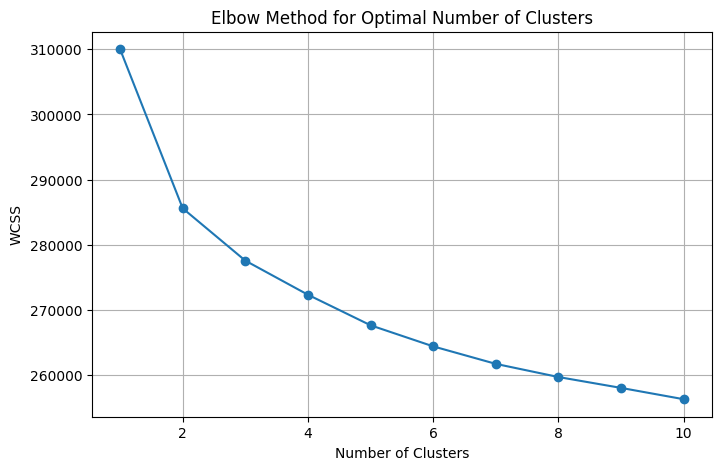


Customer Segmentation Results:
   Customer_ID  Birth_Year Education_Level Marital_Status  Annual_Income  \
0            1        1978      Graduation          Widow       40175.23   
1            2        1991             PhD          Widow       27979.68   
2            3        1968             PhD        Married       64747.68   
3            4        1954      Graduation          Widow       50185.85   
4            5        1982      Graduation        Married       53163.09   
5            6        1947      Graduation       Together       65687.04   
6            7        2000          Master          Widow       42838.91   
7            8        1960      Graduation       Together       29384.01   
8            9        1978             PhD          Widow       51046.71   
9           10        1997      Graduation       Together       54619.42   

   Kids_Home  Teens_Home Customer_Since  Last_Purchase_Recency  Spent_Wine  \
0          1           1     26-09-2010              

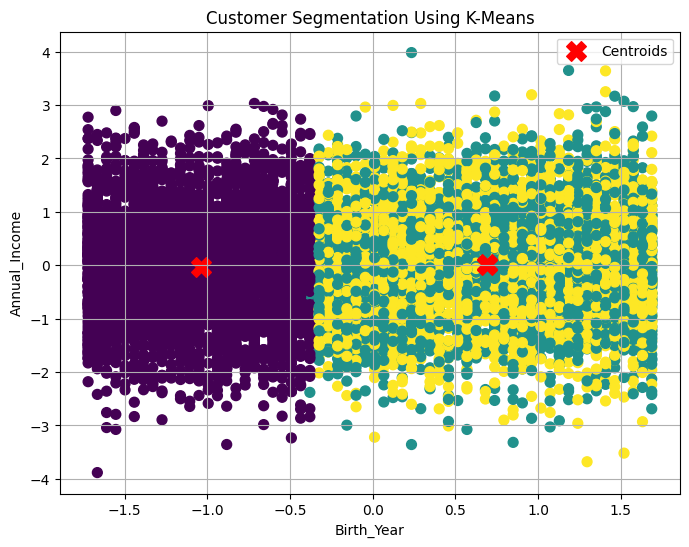


Cluster Summary:
          Birth_Year  Annual_Income  Teens_Home  Last_Purchase_Recency  \
Cluster                                                                  
0        1952.220916   49494.600683    0.997998              49.249187   
1        1983.204746   50061.132871    0.998305              49.336949   
2        1983.132329   50386.574327    0.969211              50.288896   

         Spent_Wine  Spent_Fruits  Spent_Meat  Spent_Fish  Spent_Sweets  \
Cluster                                                                   
0        488.490618     49.718289  401.080560  149.702527     99.411058   
1        697.379322     51.127458  493.777627  160.550169    103.868814   
2        317.562398     48.326236  312.203734  136.279070     94.812316   

         Spent_Gold  ...  Campaign_Response  Region_Code  Mobile_App_User  \
Cluster              ...                                                    
0        249.148111  ...           0.513885   549.067801         0.503628   
1   

In [1]:
from google.colab import files

uploaded = files.upload()
# Experiment 6
# Customer Segmentation Using K-Means Clustering

# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# --------------------------------------------------
# Step 1: Load the dataset
# --------------------------------------------------

df = pd.read_csv("customer_data.csv")

print("Customer Dataset")
print("----------------")
print(df.head())

# Display dataset information
print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

# --------------------------------------------------
# Step 2: Select numerical features
# --------------------------------------------------

# Select all numerical columns
numeric_data = df.select_dtypes(include=['int64', 'float64'])

# Remove ID columns
features = []

for column in numeric_data.columns:
    if "id" not in column.lower():
        features.append(column)

X = df[features]

print("\nFeatures used for clustering:")
print(features)

# --------------------------------------------------
# Step 3: Handle missing values
# --------------------------------------------------

X = X.fillna(X.mean())

# --------------------------------------------------
# Step 4: Standardize the data
# --------------------------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --------------------------------------------------
# Step 5: Elbow Method
# --------------------------------------------------

wcss = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

# Display WCSS values
print("\nWCSS Values:")
print(wcss)

# Plot Elbow Method
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal Number of Clusters")

plt.grid()
plt.show()

# --------------------------------------------------
# Step 6: Apply K-Means Clustering
# --------------------------------------------------

# Choose number of clusters
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Predict cluster for each customer
clusters = kmeans.fit_predict(X_scaled)

# Add cluster column to dataset
df['Cluster'] = clusters

# --------------------------------------------------
# Step 7: Display clustered customers
# --------------------------------------------------

print("\nCustomer Segmentation Results:")
print(df.head(10))

# --------------------------------------------------
# Step 8: Display number of customers in each cluster
# --------------------------------------------------

print("\nNumber of Customers in Each Cluster:")

print(df['Cluster'].value_counts().sort_index())

# --------------------------------------------------
# Step 9: Cluster visualization
# --------------------------------------------------

# Use first two features for visualization
plt.figure(figsize=(8, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=clusters,
    cmap='viridis',
    s=50
)

# Plot cluster centers
centers = kmeans.cluster_centers_

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker='X',
    s=200,
    c='red',
    label='Centroids'
)

plt.xlabel(features[0])
plt.ylabel(features[1])

plt.title("Customer Segmentation Using K-Means")

plt.legend()
plt.grid()

plt.show()

# --------------------------------------------------
# Step 10: Display cluster summary
# --------------------------------------------------

print("\nCluster Summary:")

cluster_summary = df.groupby('Cluster')[features].mean()

print(cluster_summary)